In [27]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import numpy as np


In [ ]:
#Load Dataset
df = pd.read_csv("../data/creditcard.csv")

print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Class Distribution Check (IMPORTANT )
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
# Missing Values Check
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
# Feature Scaling (Amount)
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

In [9]:
#Drop time column(optional)
df = df.drop(['Time'], axis=1)

In [11]:
# Train Test Split
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
# Handle Imbalance (SMOTE )
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_res.value_counts())

c:\Users\Habibullah\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Habibullah\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Habibullah\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Habibullah\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~

Class
0    227451
1       394
Name: count, dtype: int64
Class
0    227451
1    227451
Name: count, dtype: int64


In [15]:
# First Model (Logistic Regression)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [17]:
# Evaluation Function (Reusable)
def evaluate_model(y_test, y_pred, y_prob):
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

In [18]:
evaluate_model(y_test, y_pred_lr, y_prob_lr)

Confusion Matrix:
 [[55355  1509]
 [    8    90]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962


ROC-AUC Score: 0.970028112187475


In [21]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_rf, y_prob_rf)

Confusion Matrix:
 [[56852    12]
 [   17    81]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score: 0.9736690944667118


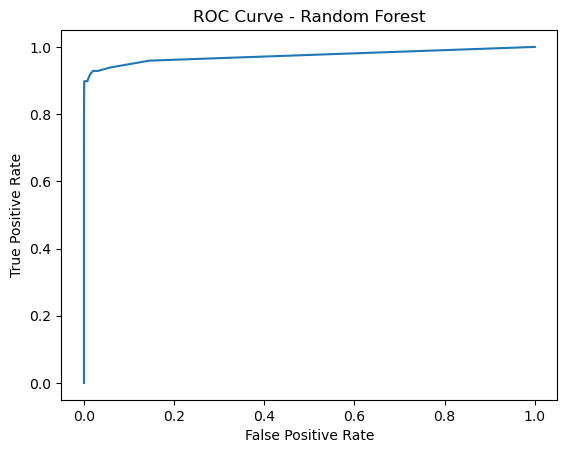

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

In [24]:
#model testing
y_prob_rf

array([0., 0., 0., ..., 0., 0., 0.])

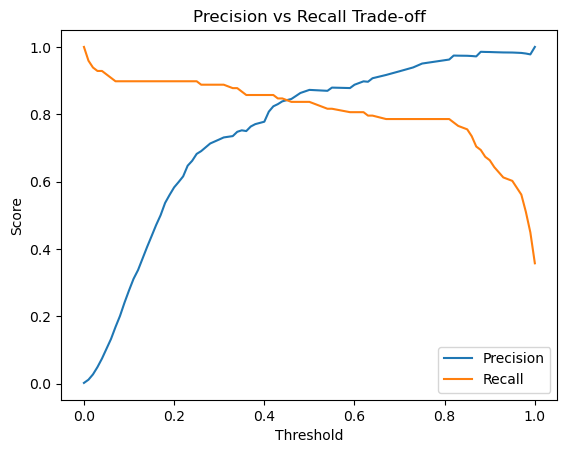

In [26]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall Trade-off")
plt.legend()
plt.show()

In [28]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best Precision:", precision[best_index])
print("Best Recall:", recall[best_index])
print("Best F1 Score:", f1_scores[best_index])

Best Threshold: 0.81
Best Precision: 0.9625
Best Recall: 0.7857142857142857
Best F1 Score: 0.865168539276354


In [29]:
y_pred_final = (y_prob_rf >= best_threshold).astype(int)

evaluate_model(y_test, y_pred_final, y_prob_rf)

Confusion Matrix:
 [[56861     3]
 [   21    77]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.79      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score: 0.9736690944667118


In [30]:
#Final Model Save (Production Version)
import joblib

joblib.dump(rf, "../models/fraud_model_final.pkl")
joblib.dump(best_threshold, "../models/threshold.pkl")

['../models/threshold.pkl']

In [31]:
fraud_sample = df[df["Class"] == 1].iloc[0]
fraud_sample

V1       -2.312227
V2        1.951992
V3       -1.609851
V4        3.997906
V5       -0.522188
V6       -1.426545
V7       -2.537387
V8        1.391657
V9       -2.770089
V10      -2.772272
V11       3.202033
V12      -2.899907
V13      -0.595222
V14      -4.289254
V15       0.389724
V16      -1.140747
V17      -2.830056
V18      -0.016822
V19       0.416956
V20       0.126911
V21       0.517232
V22      -0.035049
V23      -0.465211
V24       0.320198
V25       0.044519
V26       0.177840
V27       0.261145
V28      -0.143276
Amount   -0.353229
Class     1.000000
Name: 541, dtype: float64